In [30]:
import numpy as np
import matplotlib.pyplot as plt

## Preprocessors

In [29]:
from preprocessors import StandardScaler, MinMaxScaler
import sklearn.preprocessing

In [66]:
x = 

x_std_scaled = StandardScaler().fit_transform(x)
x_mm_scaled = MinMaxScaler().fit_transform(x)
x_std_scaled_sklearn = sklearn.preprocessing.StandardScaler().fit_transform(x.reshape(-1, 1))
x_mm_scaled_sklearn = sklearn.preprocessing.MinMaxScaler().fit_transform(x.reshape(-1, 1))



print('Standard scaling: my framework/sklearn')
print(x_std_scaled)
print(x_std_scaled_sklearn)
print('\nMinmax scaling: my framework/sklearn')
print(x_mm_scaled)
print(x_mm_scaled_sklearn)

Standard scaling: my framework/sklearn
[-0.70329763 -0.7242738   1.70419467 -0.27662325]
[[-0.70329763]
 [-0.7242738 ]
 [ 1.70419467]
 [-0.27662325]]

Minmax scaling: my framework/sklearn
[0.00863761 0.         1.         0.18433451]
[[0.00863761]
 [0.        ]
 [1.        ]
 [0.18433451]]


## Models

### Linear Regression

In [2]:
from models import LinearRegression
from metrics import r_squared
from utils import make_regression
from model_selection import random_split

In [3]:
x, y = make_regression(n_samples=1000, n_features=5, noise_coef=0.1, seed=42)
x_train, x_test, y_train, y_test = random_split(x, y, test_size=0.2, seed=42)

In [4]:
model = LinearRegression(lr=1e-2, ridge_coef=0.001, lasso_coef=0.001)
model

LinearRegression(
    max_iter=1000,
    lr=0.01,
    tol=1e-06,
    early_stopping_patience=10,
    ridge_coef=0.001,
    lasso_coef=0.001,
    trained=False
)

In [5]:
losses = model.train(x_train, y_train)
y_pred = model(x_test)
resids = y_test - y_pred

R-squared: 0.9999176805576211


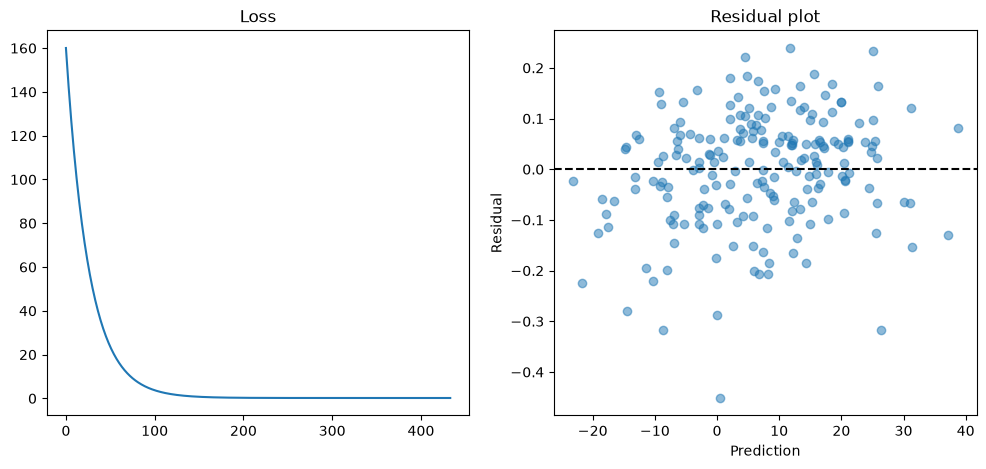

In [6]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title('Loss')

plt.subplot(1, 2, 2)
plt.scatter(y_pred, resids, alpha=0.5)
plt.title('Residual plot')
plt.xlabel('Prediction')
plt.ylabel('Residual')
plt.axhline(0, c='k', ls='--')
print("R-squared:", r_squared(y_test, y_pred))

### Logistic Regression

In [7]:
from models import LogisticRegression
from metrics import accuracy, precision, recall, f1, show_confusion_matrix
from utils import make_classification

In [8]:
x, y = make_classification(n_samples=1000, n_features=5, n_classes=2, noise_coef=1, seed=42)
x_train, x_test, y_train, y_test = random_split(x, y, test_size=0.2, seed=42)

In [9]:
model = LogisticRegression(max_iter=3000, lr=1e-1, threshold=0.5)
model

LogisticRegression(
    max_iter=3000,
    lr=0.1,
    tol=1e-06,
    early_stopping_patience=10,
    threshold=0.5,
    trained=False
)

In [10]:
losses = model.train(x_train, y_train)
y_pred = model(x_test)

Accuracy: 0.915
F1: 0.9177264289056251


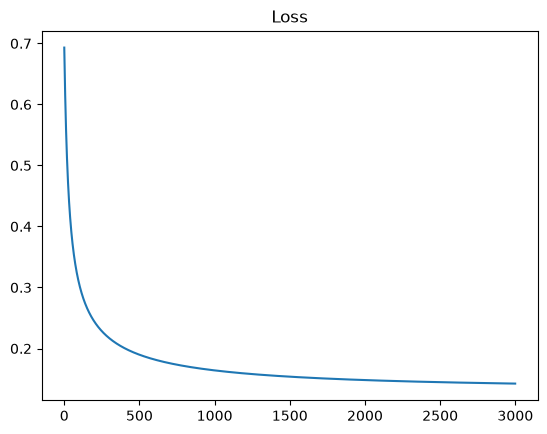

In [11]:
plt.plot(losses)
plt.title('Loss')
print("Accuracy:", accuracy(y_test, y_pred))
print("F1:", f1(y_test, y_pred))

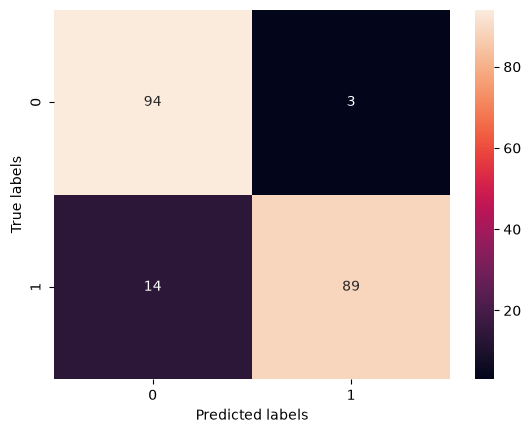

In [12]:
show_confusion_matrix(y_test, y_pred)

### KNN Classifier

In [13]:
from models import KNNClassifier

In [14]:
model = KNNClassifier(n_neighbors=5)
model

KNNClassifier(
    n_neighbors=5,
    trained=False
)

In [15]:
model.train(x_train, y_train)
y_pred = model(x_test)

In [16]:
print("Accuracy:", accuracy(y_test, y_pred))
print("F1:", f1(y_test, y_pred))

Accuracy: 0.895
F1: 0.8951778747607609


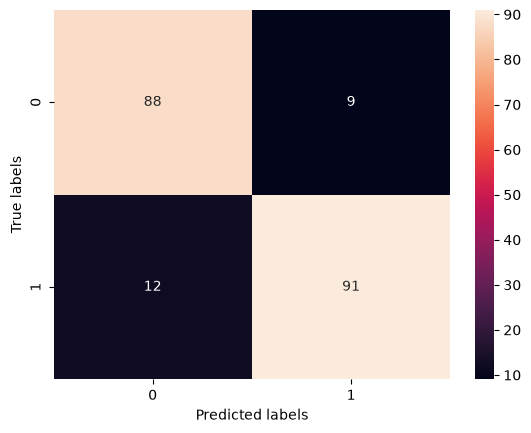

In [17]:
show_confusion_matrix(y_test, y_pred)

In [25]:
# multiclass
x, y = make_classification(n_samples=1000, n_features=10, n_classes=5, noise_coef=1, seed=42)
x_train, x_test, y_train, y_test = random_split(x, y, test_size=0.2, seed=42)

In [26]:
model.train(x_train, y_train)
y_pred = model(x_test)

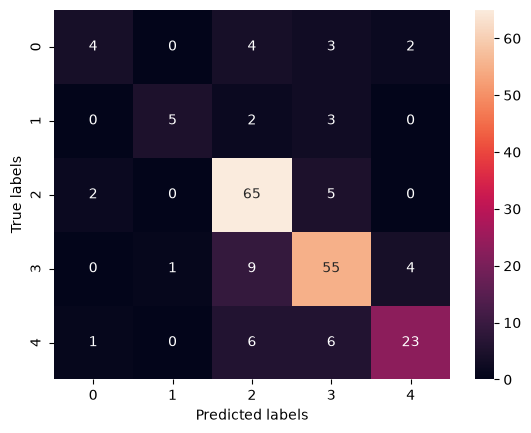

In [27]:
show_confusion_matrix(y_test, y_pred)